In [1]:
from typing import TypedDict , Literal
class PortFolioState(TypedDict):
    amount_usd : float
    total_usd : float
    target_curr : Literal["INR", "EUR", "SLR"]
    total : float

In [2]:
def calc_total(state : PortFolioState)->PortFolioState:
    state['total_usd'] = state['amount_usd']* 1.08
    
    return state

In [7]:
def convert_to_inr(state: PortFolioState)->PortFolioState:
    state['total'] = state['total_usd'] * 97.03
    return state

def convert_to_eur(state: PortFolioState)->PortFolioState:
    state['total'] = state['total_usd'] * 0.86
    return state

def convert_to_slr(state: PortFolioState)->PortFolioState:
    state['total'] = state['total_usd'] * 344.60
    return state

def choose_curr(state: PortFolioState)->str:
    return state["target_curr"]

In [10]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(PortFolioState)

builder.add_node("calc_total_node",calc_total)
builder.add_node("cvrt_to_inr_node",convert_to_inr)
builder.add_node("cvrt_to_eur_node",convert_to_eur)
builder.add_node("cvrt_to_slr_node",convert_to_slr)

builder.add_edge(START, "calc_total_node")
builder.add_conditional_edges("calc_total_node",
                              choose_curr,
                              {
                                "INR" : "cvrt_to_inr_node",
                                "EUR": "cvrt_to_eur_node",
                                "SLR" : "cvrt_to_slr_node"
                              })
builder.add_edge(["cvrt_to_inr_node", "cvrt_to_eur_node", "cvrt_to_slr_node"], END)

graph = builder.compile()

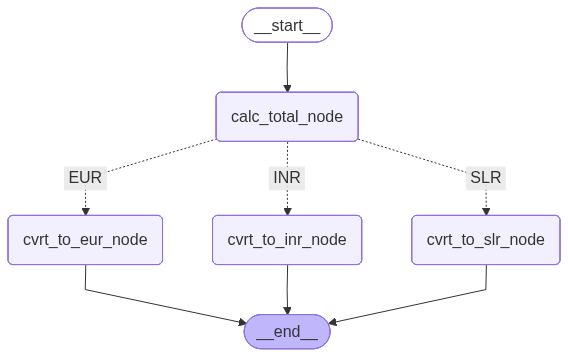

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
graph.invoke({'amount_usd':1000, 'target_curr':"SLR"})

{'amount_usd': 1000,
 'total_usd': 1080.0,
 'target_curr': 'SLR',
 'total': 372168.0}